# Multimodal Fusion Model — ECG + Echo
**Architecture:** 1D-ResNet (ECG) + ResNet50 (Echo) → Phase/Cycle Tokenizers → Cross-Attention → MLP Head  
**Training:** Stage 1 (frozen encoders) → Stage 2 (end-to-end fine-tune)  
**GPU:** RTX 4060 Laptop / CUDA 12.8

## 0. Install & GPU Check

In [ ]:
# Run once, then comment out
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
# !pip install torchmetrics scikit-learn matplotlib seaborn tqdm

In [2]:
import torch
print(f"PyTorch   : {torch.__version__}")
print(f"CUDA avail: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {DEVICE}")

PyTorch   : 2.11.0+cu128
CUDA avail: True
GPU       : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM      : 8.6 GB

Using device: cuda


In [3]:
# Cell 1 — imports + device
import torch, gc
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"VRAM free : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved(0))/1e9:.1f} GB")

VRAM total: 8.6 GB
VRAM free : 8.6 GB


## 1. Config

In [4]:
import os

# ── Paths ─────────────────────────────────────────────────────────────────────
CACHE_DIR  = r"C:\Users\anwme\Desktop\Datasets\cache"
OUTPUT_DIR = r"C:\Users\anwme\Desktop\Datasets\model_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Data ──────────────────────────────────────────────────────────────────────
ECG_LEADS   = 12
ECG_LEN     = 5000      # 500 Hz x 10 s
ECHO_SIZE   = 224
ECHO_FRAMES = 3         # ED, Mid, ES
NUM_CLASSES = 6

# ── Model ─────────────────────────────────────────────────────────────────────
ECG_BASE_DIM  = 512     # 1D-ResNet output channels
ECHO_BASE_DIM = 2048    # ResNet50 penultimate layer
PROJ_DIM      = 256     # shared projection / attention space
ATTN_HEADS    = 4
ATTN_DROPOUT  = 0.1
MLP_DROPOUT   = 0.4

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE  = 16        # safe for 8 GB VRAM; drop to 16 if OOM
NUM_WORKERS = 4

# Stage 1 - frozen encoders
S1_EPOCHS = 20
S1_LR     = 3e-4

# Stage 2 - end-to-end fine-tune
S2_EPOCHS = 30
S2_LR     = 5e-5        # lower to protect pretrained ResNet50

SEED = 42

# ── Reproducibility ───────────────────────────────────────────────────────────
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Config OK")

Config OK


## 2. Dataset & DataLoaders

In [5]:
# CELL 2 — full replacement, paste over the old one

import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

with open(os.path.join(CACHE_DIR, 'classes.json')) as f:
    meta = json.load(f)
CLASSES      = meta['classes']
CLASS_TO_IDX = meta['class_to_idx']
print(f"Classes: {CLASSES}")


class CardiacDataset(Dataset):
    def __init__(self, npz_path, augment=False):
        data         = np.load(npz_path, mmap_mode='r')
        self.ecg     = data['ecg']
        self.echo    = data['echo']
        self.labels  = data['label'].copy()
        self.augment = augment
        self.echo_mean = torch.tensor([0.449], dtype=torch.float32)
        self.echo_std  = torch.tensor([0.226], dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def _augment_ecg(self, ecg):
        ecg = ecg * np.random.uniform(0.9, 1.1)
        ecg = ecg + np.random.randn(*ecg.shape).astype(np.float32) * 0.02
        shift = np.random.randint(0, 200)
        ecg = np.concatenate([ecg[:, shift:],
                               np.zeros((ecg.shape[0], shift), dtype=np.float32)], axis=1)
        return ecg

    def _augment_echo(self, echo):
        if np.random.rand() > 0.5:
            echo = echo[:, :, ::-1].copy()
        return echo

    def __getitem__(self, idx):
        ecg  = self.ecg[idx].copy().astype(np.float32)
        echo = self.echo[idx].copy()
        lbl  = int(self.labels[idx])

        ecg = np.nan_to_num(ecg, nan=0.0, posinf=8.0, neginf=-8.0)
        ecg = np.clip(ecg, -8.0, 8.0)

        if self.augment:
            ecg  = self._augment_ecg(ecg)
            echo = self._augment_echo(echo)

        ecg_t  = torch.from_numpy(ecg)
        echo_t = torch.from_numpy(echo.astype(np.float32) / 255.0)
        echo_t = (echo_t - self.echo_mean.view(1, 1, 1)) / self.echo_std.view(1, 1, 1)

        return ecg_t, echo_t, torch.tensor(lbl, dtype=torch.long)


train_ds = CardiacDataset(os.path.join(CACHE_DIR, 'train.npz'), augment=True)
val_ds   = CardiacDataset(os.path.join(CACHE_DIR, 'val.npz'),   augment=False)
test_ds  = CardiacDataset(os.path.join(CACHE_DIR, 'test.npz'),  augment=False)

# num_workers=0 is faster on Windows (no subprocess spawn overhead)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_ds):>5}  |  Val: {len(val_ds):>5}  |  Test: {len(test_ds):>5}")

ecg_b, echo_b, lbl_b = next(iter(train_loader))
print(f"ECG batch  : {ecg_b.shape}   {ecg_b.dtype}")
print(f"Echo batch : {echo_b.shape}  {echo_b.dtype}")
print(f"Labels     : {lbl_b.shape}   unique={lbl_b.unique().tolist()}")

Classes: ['cardiomyopathy', 'heart_failure', 'ischemic_heart_disease', 'normal', 'pericardial_disease', 'valve_disease']
Train:  3163  |  Val:   459  |  Test:   946
ECG batch  : torch.Size([16, 12, 5000])   torch.float32
Echo batch : torch.Size([16, 3, 224, 224])  torch.float32
Labels     : torch.Size([16])   unique=[0, 1, 2, 3, 5]


In [6]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True,
                          prefetch_factor=2, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True,
                          prefetch_factor=2, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True,
                          prefetch_factor=2, persistent_workers=True)

In [7]:
train_ds = CardiacDataset(os.path.join(CACHE_DIR, 'train.npz'), augment=True)
val_ds   = CardiacDataset(os.path.join(CACHE_DIR, 'val.npz'),   augment=False)
test_ds  = CardiacDataset(os.path.join(CACHE_DIR, 'test.npz'),  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

Train: 3163  Val: 459  Test: 946


## 3. Model Architecture

```
ECG (12, 5000)                      Echo (3, 224, 224)
      |                                     |
 [1D-ResNet]                         [ResNet50]
  -> (256, ~156)                  per frame -> (2048,)
      |                                     |
 [Phase Tokenizer]                  [Cycle Tokenizer]
  P, QRS, T  -> (3, 256)            ED, Mid, ES -> (3, 256)
      |                                     |
      +------- [Cross-Attention] -----------+
               ECG queries <-> Echo keys/values
               Echo queries <-> ECG keys/values
                         |
              [Fused] (6 x 256) -> flatten
                         |
                     [MLP Head]
                         |
                    6 classes
```

In [8]:
# Cell 3 — verify VRAM is free before model load
print(f"VRAM allocated: {torch.cuda.memory_allocated(0)/1e6:.0f} MB")
# Should print 0 MB after fresh kernel restart

VRAM allocated: 0 MB


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models


# ─────────────────────────────────────────────────────────────────────────────
# A. ECG ENCODER  — 1D ResNet
# Input : (B, 12, 5000)
# Output: (B, 256, ~156)
# ─────────────────────────────────────────────────────────────────────────────

class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, 7, stride=stride, padding=3, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 7, padding=3, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.skip  = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm1d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.skip(x))


class ECGEncoder(nn.Module):
    def __init__(self, in_leads=12, base_dim=256):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_leads, 64, 15, stride=2, padding=7, bias=False),  # /2
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(3, stride=2, padding=1)                            # /2
        )
        self.layer1 = self._make(64,  64,       n=2, stride=1)
        self.layer2 = self._make(64,  128,      n=2, stride=2)  # /2
        self.layer3 = self._make(128, 192,      n=2, stride=2)  # /2
        self.layer4 = self._make(192, base_dim, n=2, stride=2)  # /2
        # Total: 5000 / (2*2*2*2*2) = ~156 time steps

    def _make(self, in_ch, out_ch, n, stride):
        return nn.Sequential(
            ResBlock1D(in_ch, out_ch, stride=stride),
            *[ResBlock1D(out_ch, out_ch) for _ in range(n - 1)]
        )

    def forward(self, x):         # (B, 12, 5000)
        return self.layer4(self.layer3(self.layer2(self.layer1(self.stem(x)))))
        # -> (B, 256, ~156)


# ─────────────────────────────────────────────────────────────────────────────
# B. PHASE TOKENIZER
# Splits ECG feature map into 3 equal thirds -> P, QRS, T tokens
# Output: (B, 3, proj_dim)
# ─────────────────────────────────────────────────────────────────────────────

class PhaseTokenizer(nn.Module):
    def __init__(self, in_dim=256, proj_dim=256):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.norm = nn.LayerNorm(proj_dim)

    def forward(self, x):          # x: (B, C, T)
        T = x.shape[2]
        t = T // 3
        p   = x[:, :, :t].mean(-1)       # P-wave
        qrs = x[:, :, t:2*t].mean(-1)    # QRS
        tv  = x[:, :, 2*t:].mean(-1)     # T-wave
        tokens = torch.stack([p, qrs, tv], dim=1)  # (B, 3, C)
        return self.norm(self.proj(tokens))         # (B, 3, proj_dim)


# ─────────────────────────────────────────────────────────────────────────────
# C. ECHO ENCODER — ResNet50, shared weights across 3 frames
# Output: (B, 3, 2048)
# ─────────────────────────────────────────────────────────────────────────────

class EchoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        bb = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Adapt first conv: 3-ch -> 1-ch (grayscale), preserve weight scale
        old = bb.conv1
        new = nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False)
        new.weight.data = old.weight.data.mean(dim=1, keepdim=True)
        bb.conv1 = new
        self.backbone = nn.Sequential(*list(bb.children())[:-1])  # remove fc

    def forward(self, echo):       # echo: (B, 3, H, W)
        B, F, H, W = echo.shape
        x = echo.reshape(B * F, 1, H, W)
        x = self.backbone(x).flatten(1)   # (B*3, 2048)
        return x.reshape(B, F, -1)        # (B, 3, 2048)


# ─────────────────────────────────────────────────────────────────────────────
# D. CYCLE TOKENIZER
# Projects echo frame features into shared dim
# Output: (B, 3, proj_dim)
# ─────────────────────────────────────────────────────────────────────────────

class CycleTokenizer(nn.Module):
    def __init__(self, in_dim=2048, proj_dim=256):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.norm = nn.LayerNorm(proj_dim)

    def forward(self, x):          # (B, 3, 2048)
        return self.norm(self.proj(x))  # (B, 3, proj_dim)


# ─────────────────────────────────────────────────────────────────────────────
# E. CROSS-ATTENTION FUSION  (bidirectional)
# ─────────────────────────────────────────────────────────────────────────────

class CrossAttentionFusion(nn.Module):
    """
    ECG tokens  (queries) attend to Echo tokens -> ecg_fused  (B, 3, D)
    Echo tokens (queries) attend to ECG tokens  -> echo_fused (B, 3, D)
    The 3x3 attention matrix is saved as self.attn_weights for EAM plots.
    """
    def __init__(self, dim=256, num_heads=4, dropout=0.1):
        super().__init__()
        self.ecg_to_echo = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.echo_to_ecg = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm_ecg    = nn.LayerNorm(dim)
        self.norm_echo   = nn.LayerNorm(dim)
        self.attn_weights = None   # stored for EAM visualisation

    def forward(self, ecg_tok, echo_tok):
        # ecg_tok : (B, 3, D)  |  echo_tok: (B, 3, D)
        ecg_fused,  w_ecg  = self.ecg_to_echo(ecg_tok,  echo_tok, echo_tok)
        echo_fused, w_echo = self.echo_to_ecg(echo_tok, ecg_tok,  ecg_tok)

        ecg_fused  = self.norm_ecg( ecg_tok  + ecg_fused)
        echo_fused = self.norm_echo(echo_tok + echo_fused)

        # Save for EAM  (averaged over heads, shape: B x 3 x 3)
        self.attn_weights = {
            'ecg_to_echo': w_ecg.detach().cpu(),
            'echo_to_ecg': w_echo.detach().cpu()
        }

        fused = torch.cat([ecg_fused, echo_fused], dim=1)  # (B, 6, D)
        return fused.flatten(1)                            # (B, 6*D)


# ─────────────────────────────────────────────────────────────────────────────
# F. FULL FUSION MODEL
# ─────────────────────────────────────────────────────────────────────────────

class CardiacFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.ecg_encoder  = ECGEncoder(in_leads=ECG_LEADS, base_dim=ECG_BASE_DIM)
        self.echo_encoder = EchoEncoder()
        self.phase_tok    = PhaseTokenizer(in_dim=ECG_BASE_DIM,  proj_dim=PROJ_DIM)
        self.cycle_tok    = CycleTokenizer(in_dim=ECHO_BASE_DIM, proj_dim=PROJ_DIM)
        # Learnable positional embeddings
        self.ecg_pos  = nn.Parameter(torch.randn(1, 3, PROJ_DIM) * 0.02)
        self.echo_pos = nn.Parameter(torch.randn(1, 3, PROJ_DIM) * 0.02)
        self.fusion   = CrossAttentionFusion(PROJ_DIM, ATTN_HEADS, ATTN_DROPOUT)
        # MLP head: (6 x 256) -> 6 classes
        fused_dim = PROJ_DIM * 6
        self.head = nn.Sequential(
            nn.Linear(fused_dim, 512), nn.GELU(), nn.Dropout(MLP_DROPOUT),
            nn.Linear(512, 128),       nn.GELU(), nn.Dropout(MLP_DROPOUT / 2),
            nn.Linear(128, NUM_CLASSES)
        )

    def forward(self, ecg, echo):
        ecg_feat  = self.ecg_encoder(ecg)                          # (B, 256, ~156)
        echo_feat = self.echo_encoder(echo)                        # (B, 3, 2048)
        ecg_tok   = self.phase_tok(ecg_feat)  + self.ecg_pos       # (B, 3, 256)
        echo_tok  = self.cycle_tok(echo_feat) + self.echo_pos      # (B, 3, 256)
        fused     = self.fusion(ecg_tok, echo_tok)                 # (B, 6*256)
        return self.head(fused)                                    # (B, 6)

    def freeze_encoders(self):
        for p in self.ecg_encoder.parameters():  p.requires_grad = False
        for p in self.echo_encoder.parameters(): p.requires_grad = False
        print("Encoders FROZEN.")

    def unfreeze_all(self):
        for p in self.parameters(): p.requires_grad = True
        print("All layers UNFROZEN.")

    def count_params(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Total params    : {total/1e6:.2f} M")
        print(f"Trainable params: {trainable/1e6:.2f} M")


# ── Instantiate & dry-run ──────────────────────────────────────────────────────
model = CardiacFusionModel().to(DEVICE)
model.count_params()

with torch.no_grad():
    o = model(torch.randn(2, 12, 5000).to(DEVICE),
              torch.randn(2, 3, 224, 224).to(DEVICE))
print(f"Dry-run output: {o.shape}  <- (batch=2, classes={NUM_CLASSES})")

Total params    : 33.35 M
Trainable params: 33.35 M
Dry-run output: torch.Size([2, 6])  <- (batch=2, classes=6)


In [11]:
model = CardiacFusionModel().to(DEVICE)

# Verify NaN is gone before training
model.eval()
with torch.no_grad():
    ecg_b, echo_b, _ = next(iter(val_loader))
    out = model(ecg_b.to(DEVICE), echo_b.to(DEVICE))
    print(f"Logits max: {out.abs().max():.3f}  NaN: {torch.isnan(out).any()}")

Logits max: 0.124  NaN: False


In [12]:
# ── After replacing ResBlock1D and ECGEncoder classes, run this ───────────────

# 1. Re-instantiate the model fresh
model = CardiacFusionModel().to(DEVICE)

# 2. Step-by-step stem check
model.eval()
ecg_b = next(iter(val_loader))[0].to(DEVICE)

with torch.no_grad():
    x = ecg_b
    print(f"Input : max={x.abs().max():.3f}  nan={torch.isnan(x).any()}")

    # Check each sub-layer of stem individually
    stem_layers = list(model.ecg_encoder.stem.children())
    for name, layer in zip(['Conv1d','BN','ReLU','MaxPool'], stem_layers):
        x = layer(x)
        print(f"  {name:10s}: max={x.abs().max():.3f}  nan={torch.isnan(x).any()}")

    x = model.ecg_encoder.layer1(x)
    print(f"Layer1 : max={x.abs().max():.3f}  nan={torch.isnan(x).any()}")
    x = model.ecg_encoder.layer2(x)
    print(f"Layer2 : max={x.abs().max():.3f}  nan={torch.isnan(x).any()}")
    x = model.ecg_encoder.layer3(x)
    print(f"Layer3 : max={x.abs().max():.3f}  nan={torch.isnan(x).any()}")
    x = model.ecg_encoder.layer4(x)
    print(f"Layer4 : max={x.abs().max():.3f}  nan={torch.isnan(x).any()}")

    # Full forward
    echo_b = next(iter(val_loader))[1].to(DEVICE)
    out = model(ecg_b, echo_b)
    print(f"\nFull forward — Logits max: {out.abs().max():.3f}  NaN: {torch.isnan(out).any()}")
    print("✓ Ready to train" if not torch.isnan(out).any() else "✗ Still NaN — share output")

Input : max=8.000  nan=False
  Conv1d    : max=9.369  nan=False
  BN        : max=9.369  nan=False
  ReLU      : max=9.369  nan=False
  MaxPool   : max=9.369  nan=False
Layer1 : max=8.465  nan=False
Layer2 : max=4.888  nan=False
Layer3 : max=2.935  nan=False
Layer4 : max=1.155  nan=False

Full forward — Logits max: 0.217  NaN: False
✓ Ready to train


## 4. Training Utilities

In [13]:
# ── CELL 4 — Training Utilities (fixed) ──────────────────────────────────────
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def compute_class_weights(dataset):
    counts  = np.bincount(dataset.labels, minlength=NUM_CLASSES).astype(float)
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * NUM_CLASSES
    # Clamp: prevent any single class from dominating with extreme weight
    weights = np.clip(weights, 0.1, 2.0)
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = correct = total = nan_batches = 0

    # Device-aware autocast: only use float16 on CUDA, bfloat16 on CPU
    use_amp = DEVICE.type == 'cuda'

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for ecg, echo, labels in loader:
            ecg    = ecg.to(DEVICE)
            echo   = echo.to(DEVICE)
            labels = labels.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            if use_amp:
                with torch.autocast('cuda', torch.float16):
                    logits = model(ecg, echo)
                    loss   = criterion(logits, labels)
            else:
                logits = model(ecg, echo)
                loss   = criterion(logits, labels)

            # Skip NaN batches instead of letting them corrupt weights
            if torch.isnan(loss) or torch.isinf(loss):
                nan_batches += 1
                if is_train:
                    optimizer.zero_grad()
                continue

            if is_train:
                if use_amp and scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

            total_loss += loss.item() * labels.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)

    if nan_batches:
        print(f"  ⚠️  Skipped {nan_batches} NaN batches")

    if total == 0:
        return float('nan'), 0.0
    return total_loss / total, correct / total


def evaluate_full(model, loader):
    model.eval()
    preds, trues = [], []
    use_amp = DEVICE.type == 'cuda'
    with torch.no_grad():
        for ecg, echo, labels in loader:
            if use_amp:
                with torch.autocast('cuda', torch.float16):
                    logits = model(ecg.to(DEVICE), echo.to(DEVICE))
            else:
                logits = model(ecg.to(DEVICE), echo.to(DEVICE))
            preds.extend(logits.argmax(1).cpu().tolist())
            trues.extend(labels.tolist())
    return np.array(trues), np.array(preds)


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, key, ylabel in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
        ax.plot(history[f'train_{key}'], label='Train')
        ax.plot(history[f'val_{key}'],   label='Val')
        ax.set_title(f'{title} — {ylabel}')
        ax.set_xlabel('Epoch')
        ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'history_{title}.png'), dpi=150)
    plt.show()


def plot_confusion(true_labels, pred_labels, title):
    cm = confusion_matrix(true_labels, pred_labels)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'cm_{title}.png'), dpi=150)
    plt.show()


# ── Quick NaN pre-check before training ──────────────────────────────────────
print("Running NaN pre-check on one batch...")
model.eval()
with torch.no_grad():
    ecg_b, echo_b, lbl_b = next(iter(train_loader))
    out = model(ecg_b.to(DEVICE), echo_b.to(DEVICE))
    print(f"  Logits min/max : {out.min():.3f} / {out.max():.3f}")
    print(f"  Any NaN        : {torch.isnan(out).any().item()}")
    print(f"  Any Inf        : {torch.isinf(out).any().item()}")
print("Pre-check done.\n")

print("Utilities ready.")

Running NaN pre-check on one batch...
  Logits min/max : -0.230 / 0.107
  Any NaN        : False
  Any Inf        : False
Pre-check done.

Utilities ready.


In [14]:
# ── Scan all splits for NaN/Inf samples ──────────────────────────────────────
for name, ds in [('train', train_ds), ('val', val_ds), ('test', test_ds)]:
    bad_ecg = bad_echo = 0
    for i in range(len(ds)):
        ecg  = ds.ecg[i]
        echo = ds.echo[i]
        if np.isnan(ecg).any()  or np.isinf(ecg).any():  bad_ecg  += 1
        if np.isnan(echo).any() or np.isinf(echo).any(): bad_echo += 1
    print(f"{name:6s} — bad ECG: {bad_ecg}  bad Echo: {bad_echo}  total: {len(ds)}")

train  — bad ECG: 0  bad Echo: 0  total: 3163
val    — bad ECG: 0  bad Echo: 0  total: 459
test   — bad ECG: 0  bad Echo: 0  total: 946


## 5. Stage 1 — Frozen Encoders

Class weights: {'cardiomyopathy': '0.373', 'heart_failure': '0.144', 'ischemic_heart_disease': '0.100', 'normal': '0.198', 'pericardial_disease': '2.000', 'valve_disease': '1.039'}
Encoders FROZEN.
Total params    : 33.35 M
Trainable params: 2.04 M

 Stage 1: 20 epochs  |  LR=0.0003  |  Device=cuda
 AMP enabled: True
Ep 001/20 | tr 2.2376/0.1581 | val 2.2338/0.0871 | 20.6s  <- BEST
Ep 002/20 | tr 2.2268/0.1723 | val 2.2344/0.0196 | 19.7s
Ep 003/20 | tr 2.0829/0.2611 | val 2.3297/0.1874 | 19.9s  <- BEST
Ep 004/20 | tr 1.8034/0.5251 | val 2.4399/0.1678 | 19.6s
Ep 005/20 | tr 1.6187/0.6260 | val 2.4354/0.2636 | 21.0s  <- BEST
Ep 006/20 | tr 1.4797/0.7341 | val 2.4599/0.2353 | 19.9s
Ep 007/20 | tr 1.4013/0.7872 | val 2.4352/0.3159 | 19.7s  <- BEST
Ep 008/20 | tr 1.3517/0.8283 | val 2.4697/0.3181 | 19.7s  <- BEST
Ep 009/20 | tr 1.2825/0.8587 | val 2.5792/0.2941 | 19.6s
Ep 010/20 | tr 1.2506/0.8799 | val 2.5558/0.3486 | 19.8s  <- BEST
Ep 011/20 | tr 1.2236/0.9010 | val 2.4613/0.3420 | 19.6s


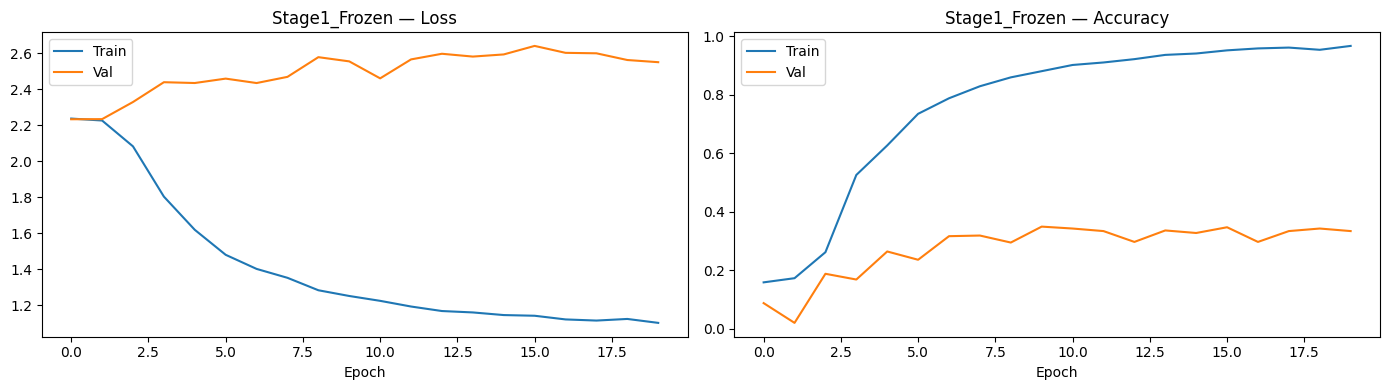

In [15]:
# ── CELL 5 — Stage 1: Frozen Encoders ────────────────────────────────
class_weights = compute_class_weights(train_ds)
print("Class weights:", {CLASSES[i]: f"{class_weights[i]:.3f}" for i in range(NUM_CLASSES)})
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

model.freeze_encoders()
model.count_params()

s1_opt = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=S1_LR, weight_decay=1e-4
)
s1_sched = torch.optim.lr_scheduler.CosineAnnealingLR(s1_opt, T_max=S1_EPOCHS, eta_min=1e-5)
# Scaler only used on CUDA
scaler   = torch.amp.GradScaler() if DEVICE.type == 'cuda' else None
ckpt_s1  = os.path.join(OUTPUT_DIR, 'stage1_best.pt')

best_acc   = 0.0
s1_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"\n{'='*65}")
print(f" Stage 1: {S1_EPOCHS} epochs  |  LR={S1_LR}  |  Device={DEVICE}")
print(f" AMP enabled: {DEVICE.type == 'cuda'}")
print(f"{'='*65}")

for ep in range(1, S1_EPOCHS + 1):
    t0 = time.time()
    tl, ta = run_epoch(model, train_loader, criterion, s1_opt, scaler)
    vl, va = run_epoch(model, val_loader,   criterion)
    s1_sched.step()

    for k, v in zip(['train_loss','val_loss','train_acc','val_acc'], [tl,vl,ta,va]):
        s1_history[k].append(v)

    flag = ''
    if va > best_acc:
        best_acc = va
        torch.save(model.state_dict(), ckpt_s1)
        flag = '  <- BEST'

    print(f"Ep {ep:03d}/{S1_EPOCHS} | tr {tl:.4f}/{ta:.4f} | val {vl:.4f}/{va:.4f} | "
          f"{time.time()-t0:.1f}s{flag}")

print(f"\nBest Stage-1 val accuracy: {best_acc:.4f}")
plot_history(s1_history, 'Stage1_Frozen')

In [16]:
# ── NaN DIAGNOSIS ─────────────────────────────────────────────────────────────
model.eval()
ecg_b, echo_b, lbl_b = next(iter(val_loader))
ecg_b, echo_b = ecg_b.to(DEVICE), echo_b.to(DEVICE)

print("=== Input stats ===")
print(f"ECG  : min={ecg_b.min():.3f}  max={ecg_b.max():.3f}  nan={torch.isnan(ecg_b).any()}")
print(f"Echo : min={echo_b.min():.3f}  max={echo_b.max():.3f}  nan={torch.isnan(echo_b).any()}")

print("\n=== Forward pass (float32, no AMP) ===")
with torch.no_grad():
    ecg_feat = model.ecg_encoder(ecg_b)
    print(f"ECG encoder  : min={ecg_feat.min():.3f} max={ecg_feat.max():.3f} nan={torch.isnan(ecg_feat).any()}")

    echo_feat = model.echo_encoder(echo_b)
    print(f"Echo encoder : min={echo_feat.min():.3f} max={echo_feat.max():.3f} nan={torch.isnan(echo_feat).any()}")

    ecg_tok  = model.phase_tok(ecg_feat) + model.ecg_pos
    echo_tok = model.cycle_tok(echo_feat) + model.echo_pos
    print(f"ECG tokens   : min={ecg_tok.min():.3f}  max={ecg_tok.max():.3f}  nan={torch.isnan(ecg_tok).any()}")
    print(f"Echo tokens  : min={echo_tok.min():.3f}  max={echo_tok.max():.3f}  nan={torch.isnan(echo_tok).any()}")

    fused = model.fusion(ecg_tok, echo_tok)
    print(f"Fusion out   : min={fused.min():.3f}  max={fused.max():.3f}  nan={torch.isnan(fused).any()}")

    logits = model.head(fused)
    print(f"Logits       : min={logits.min():.3f}  max={logits.max():.3f}  nan={torch.isnan(logits).any()}")

print("\n=== Same pass WITH AMP float16 ===")
with torch.no_grad():
    with torch.autocast('cuda', torch.float16):
        ecg_feat  = model.ecg_encoder(ecg_b)
        echo_feat = model.echo_encoder(echo_b)
        print(f"ECG encoder  (fp16): nan={torch.isnan(ecg_feat).any()}  max={ecg_feat.abs().max():.1f}")
        print(f"Echo encoder (fp16): nan={torch.isnan(echo_feat).any()}  max={echo_feat.abs().max():.1f}")
        ecg_tok   = model.phase_tok(ecg_feat) + model.ecg_pos
        echo_tok  = model.cycle_tok(echo_feat) + model.echo_pos
        print(f"ECG tokens   (fp16): nan={torch.isnan(ecg_tok).any()}  max={ecg_tok.abs().max():.1f}")
        print(f"Echo tokens  (fp16): nan={torch.isnan(echo_tok).any()}  max={echo_tok.abs().max():.1f}")
        fused  = model.fusion(ecg_tok, echo_tok)
        print(f"Fusion       (fp16): nan={torch.isnan(fused).any()}  max={fused.abs().max():.1f}")
        logits = model.head(fused)
        print(f"Logits       (fp16): nan={torch.isnan(logits).any()}  max={logits.abs().max():.1f}")

=== Input stats ===
ECG  : min=-8.000  max=8.000  nan=False
Echo : min=-1.761  max=1.362  nan=False

=== Forward pass (float32, no AMP) ===
ECG encoder  : min=0.000 max=10.549 nan=False
Echo encoder : min=0.000 max=6.669 nan=False
ECG tokens   : min=-12.410  max=5.706  nan=False
Echo tokens  : min=-3.697  max=3.778  nan=False
Fusion out   : min=-9.652  max=5.244  nan=False
Logits       : min=-1.786  max=2.363  nan=False

=== Same pass WITH AMP float16 ===
ECG encoder  (fp16): nan=False  max=10.5
Echo encoder (fp16): nan=False  max=6.7
ECG tokens   (fp16): nan=False  max=12.4
Echo tokens  (fp16): nan=False  max=3.7
Fusion       (fp16): nan=False  max=9.7
Logits       (fp16): nan=False  max=2.4


In [17]:
# Pinpoint which ECG encoder layer explodes
model.eval()
ecg_b = next(iter(val_loader))[0].to(DEVICE)

with torch.no_grad():
    x = ecg_b
    print(f"Input     : max={x.abs().max():.3f}  nan={torch.isnan(x).any()}")
    x = model.ecg_encoder.stem(x)
    print(f"Stem      : max={x.abs().max():.3f}  nan={torch.isnan(x).any()}")
    x = model.ecg_encoder.layer1(x)
    print(f"Layer1    : max={x.abs().max():.3f}  nan={torch.isnan(x).any()}")
    x = model.ecg_encoder.layer2(x)
    print(f"Layer2    : max={x.abs().max():.3f}  nan={torch.isnan(x).any()}")
    x = model.ecg_encoder.layer3(x)
    print(f"Layer3    : max={x.abs().max():.3f}  nan={torch.isnan(x).any()}")
    x = model.ecg_encoder.layer4(x)
    print(f"Layer4    : max={x.abs().max():.3f}  nan={torch.isnan(x).any()}")

Input     : max=8.000  nan=False
Stem      : max=14.523  nan=False
Layer1    : max=21.697  nan=False
Layer2    : max=16.650  nan=False
Layer3    : max=13.238  nan=False
Layer4    : max=10.549  nan=False


## 6. Stage 2 — End-to-End Fine-Tuning

All layers UNFROZEN.
Total params    : 33.35 M
Trainable params: 33.35 M

 Stage 2: 30 epochs  |  LR = 5e-05  |  All layers UNFROZEN
Ep 001/30 | tr 1.2004/0.9127 | val 2.5740/0.2919 | 43.3s  <- BEST
Ep 002/30 | tr 1.1387/0.9396 | val 2.5723/0.4052 | 43.2s  <- BEST
Ep 003/30 | tr 1.1191/0.9636 | val 2.5252/0.3704 | 41.4s
Ep 004/30 | tr 1.1108/0.9696 | val 2.5375/0.3529 | 40.9s
Ep 005/30 | tr 1.0994/0.9769 | val 2.5661/0.3464 | 40.9s
Ep 006/30 | tr 1.0774/0.9813 | val 2.5935/0.3355 | 40.9s
Ep 007/30 | tr 1.0678/0.9836 | val 2.5484/0.3420 | 41.0s
Ep 008/30 | tr 1.0714/0.9908 | val 2.5908/0.3224 | 41.4s
Ep 009/30 | tr 1.0635/0.9953 | val 2.5989/0.3050 | 41.1s
Ep 010/30 | tr 1.0493/0.9953 | val 2.5440/0.3529 | 41.1s
Early stopping at epoch 10

Best Stage-2 val accuracy: 0.4052


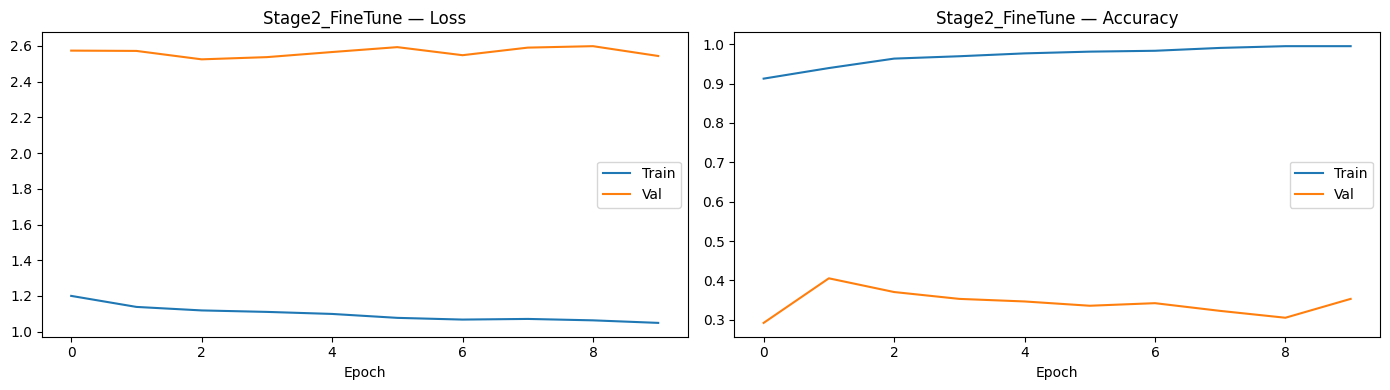

In [18]:
# Start from best Stage-1 weights
model.load_state_dict(torch.load(ckpt_s1, map_location=DEVICE))
model.unfreeze_all()
model.count_params()

# Differential learning rates:
#   - ResNet50 backbone: very low LR (pretrained ImageNet weights)
#   - ECG encoder: moderate (trained only in S1)
#   - New fusion layers / head: full S2_LR
s2_opt = torch.optim.AdamW([
    {'params': model.echo_encoder.parameters(),            'lr': S2_LR * 0.1},
    {'params': model.ecg_encoder.parameters(),             'lr': S2_LR * 0.5},
    {'params': list(model.phase_tok.parameters()) +
               list(model.cycle_tok.parameters()) +
               list(model.fusion.parameters())   +
               list(model.head.parameters())     +
               [model.ecg_pos, model.echo_pos],            'lr': S2_LR},
], weight_decay=1e-4)

s2_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(s2_opt, T_max=S2_EPOCHS, eta_min=1e-6)
scaler    = torch.amp.GradScaler()
ckpt_s2   = os.path.join(OUTPUT_DIR, 'stage2_best.pt')

best_acc   = 0.0
no_improve = 0
patience   = 8
s2_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"\n{'='*65}")
print(f" Stage 2: {S2_EPOCHS} epochs  |  LR = {S2_LR}  |  All layers UNFROZEN")
print(f"{'='*65}")

for ep in range(1, S2_EPOCHS + 1):
    t0 = time.time()
    tl, ta = run_epoch(model, train_loader, criterion, s2_opt, scaler)
    vl, va = run_epoch(model, val_loader,   criterion)
    s2_sched.step()

    for k, v in zip(['train_loss','val_loss','train_acc','val_acc'], [tl,vl,ta,va]):
        s2_history[k].append(v)

    flag = ''
    if va > best_acc:
        best_acc = va
        torch.save(model.state_dict(), ckpt_s2)
        no_improve = 0
        flag = '  <- BEST'
    else:
        no_improve += 1

    print(f"Ep {ep:03d}/{S2_EPOCHS} | tr {tl:.4f}/{ta:.4f} | val {vl:.4f}/{va:.4f} | "
          f"{time.time()-t0:.1f}s{flag}")

    if no_improve >= patience:
        print(f"Early stopping at epoch {ep}")
        break

print(f"\nBest Stage-2 val accuracy: {best_acc:.4f}")
plot_history(s2_history, 'Stage2_FineTune')

## 7. Test Set Evaluation

TEST SET RESULTS
                        precision    recall  f1-score   support

        cardiomyopathy      0.105     0.090     0.097       111
         heart_failure      0.313     0.294     0.303       228
ischemic_heart_disease      0.444     0.456     0.450       408
                normal      0.185     0.333     0.238       108
   pericardial_disease      1.000     0.019     0.037        53
         valve_disease      0.045     0.026     0.033        38

              accuracy                          0.318       946
             macro avg      0.349     0.203     0.193       946
          weighted avg      0.358     0.318     0.309       946



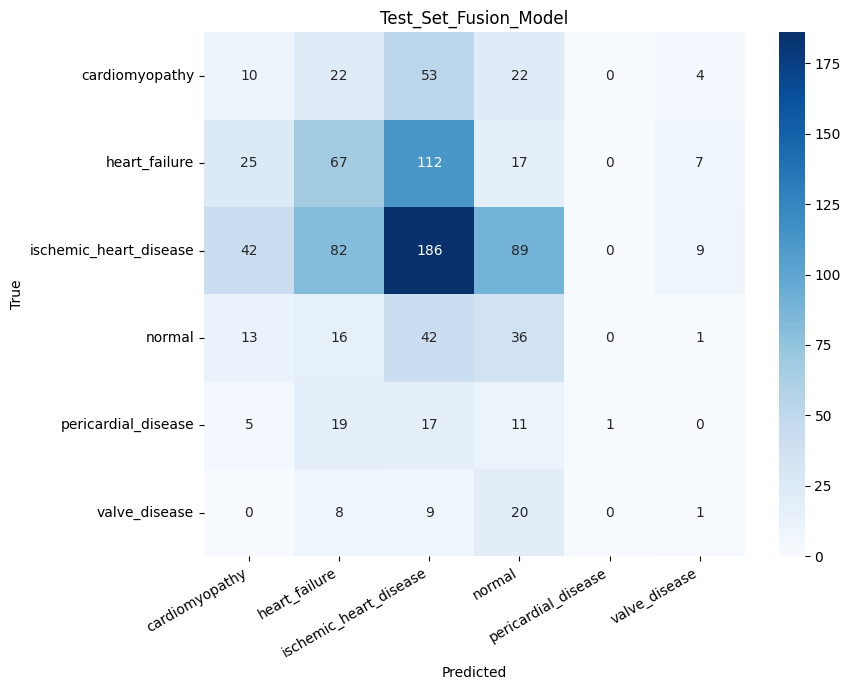

In [19]:
model.load_state_dict(torch.load(ckpt_s2, map_location=DEVICE))
true_labels, pred_labels = evaluate_full(model, test_loader)

print("=" * 65)
print("TEST SET RESULTS")
print("=" * 65)
print(classification_report(true_labels, pred_labels, target_names=CLASSES, digits=3))
plot_confusion(true_labels, pred_labels, 'Test_Set_Fusion_Model')

## 8. Electromechanical Attribution Map (EAM)

Visualises the **3×3 cross-attention matrix** (ECG phase tokens × Echo cycle tokens).  
In a healthy LBBB case you should see high attention between **QRS** (row 1) and **End-Systole** (col 2).

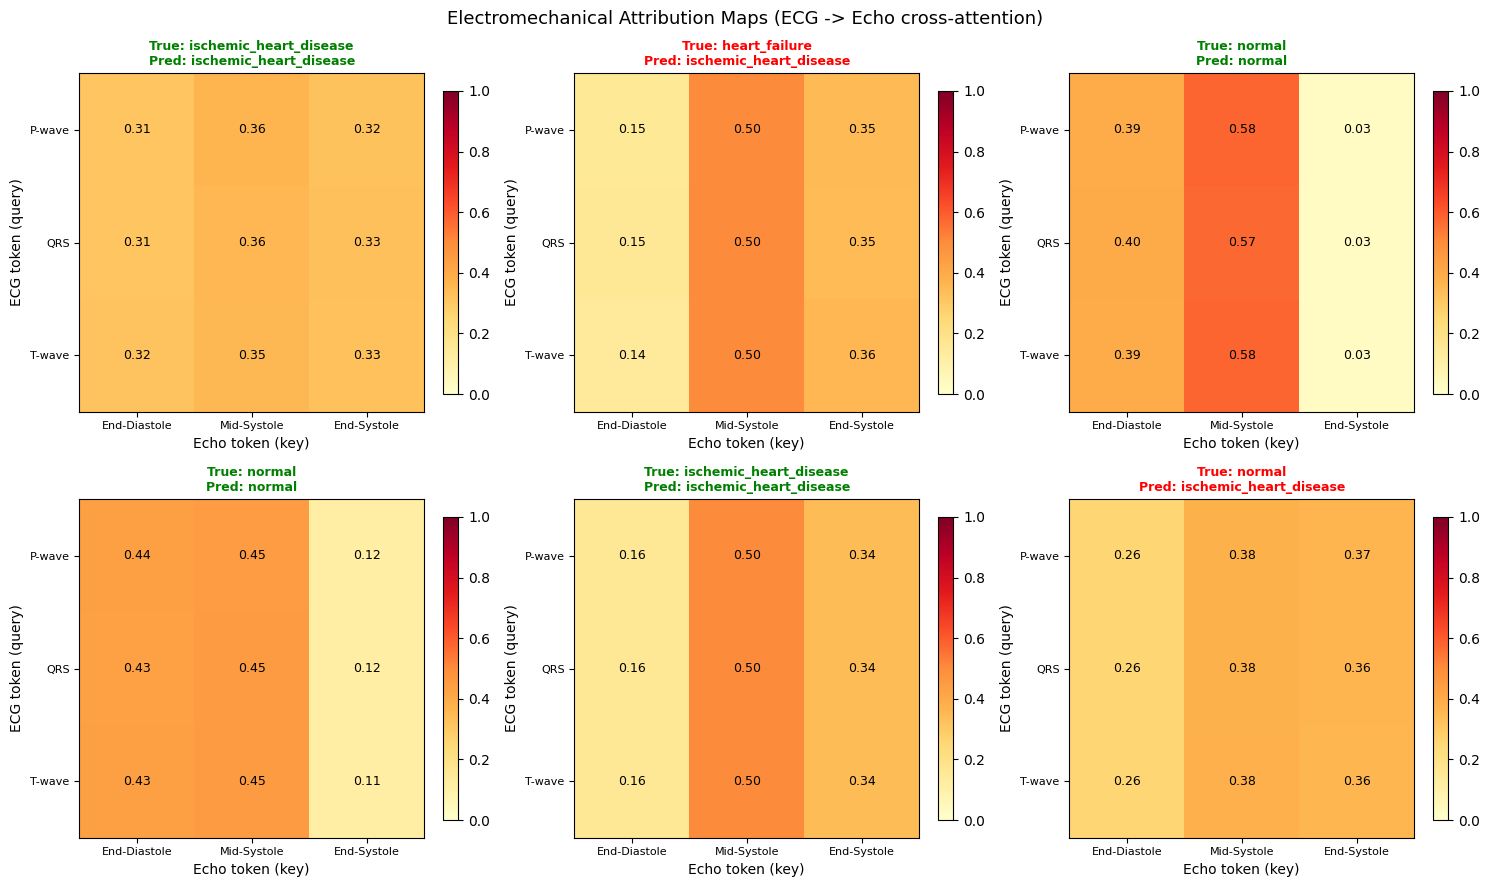

In [20]:
ECG_TOK_NAMES  = ['P-wave', 'QRS', 'T-wave']
ECHO_TOK_NAMES = ['End-Diastole', 'Mid-Systole', 'End-Systole']

def plot_eam(model, loader, num_samples=6):
    model.eval()
    collected = []
    with torch.no_grad():
        for ecg, echo, labels in loader:
            with torch.autocast('cuda', torch.float16):
                logits = model(ecg.to(DEVICE), echo.to(DEVICE))
            preds = logits.argmax(1).cpu()
            w = model.fusion.attn_weights['ecg_to_echo'].float()  # (B, 3, 3)
            for i in range(len(labels)):
                collected.append(dict(
                    attn    = w[i].numpy(),
                    true    = CLASSES[labels[i]],
                    pred    = CLASSES[preds[i]],
                    correct = (labels[i] == preds[i]).item()
                ))
            if len(collected) >= num_samples:
                break

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for ax, s in zip(axes.flat, collected):
        im = ax.imshow(s['attn'], vmin=0, vmax=1, cmap='YlOrRd', aspect='auto')
        ax.set_xticks(range(3));  ax.set_xticklabels(ECHO_TOK_NAMES, fontsize=8)
        ax.set_yticks(range(3));  ax.set_yticklabels(ECG_TOK_NAMES,  fontsize=8)
        ax.set_xlabel('Echo token (key)')
        ax.set_ylabel('ECG token (query)')
        color = 'green' if s['correct'] else 'red'
        ax.set_title(f"True: {s['true']}\nPred: {s['pred']}",
                     color=color, fontsize=9, fontweight='bold')
        for r in range(3):
            for c in range(3):
                ax.text(c, r, f"{s['attn'][r,c]:.2f}", ha='center', va='center', fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.04)

    plt.suptitle('Electromechanical Attribution Maps (ECG -> Echo cross-attention)', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'eam_samples.png'), dpi=150)
    plt.show()


plot_eam(model, test_loader, num_samples=6)

## 9. Save Final Checkpoint

In [21]:
final_path = os.path.join(OUTPUT_DIR, 'cardiac_fusion_final.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'classes'         : CLASSES,
    'class_to_idx'    : CLASS_TO_IDX,
    'config': dict(
        ecg_base_dim=ECG_BASE_DIM, echo_base_dim=ECHO_BASE_DIM,
        proj_dim=PROJ_DIM, attn_heads=ATTN_HEADS, num_classes=NUM_CLASSES
    ),
    's1_history': s1_history,
    's2_history': s2_history,
}, final_path)

print(f"Saved: {final_path}")
print("\nAll output files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    mb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1e6
    print(f"  {f:45s}  {mb:7.1f} MB")

Saved: C:\Users\anwme\Desktop\Datasets\model_output\cardiac_fusion_final.pt

All output files:
  cardiac_fusion_final.pt                          133.8 MB
  cm_Test_Set_Fusion_Model.png                       0.1 MB
  eam_samples.png                                    0.2 MB
  history_Stage1_Frozen.png                          0.1 MB
  history_Stage2_FineTune.png                        0.0 MB
  stage1_best.pt                                   133.8 MB
  stage2_best.pt                                   133.8 MB
